In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pylab as plt

In [2]:
data = pd.read_csv(r"C:\Users\maria\Videos\Mass Shooters.csv")
data.head().T

,0,1,2,3,4
Case_No,198,199,200,4,13
Shooter_Last_Name,Posey,Davis,Gray,Pearson,Henry
Shooter_First_Name,Travis,Rhanni,Colt,Eric,Dewitt
Full_Date,2024-06-21,2024-09-02,2024-09-04,1968-03-16,1977-07-23
Day_of_Week,Friday,Monday,Wednesday,Saturday,Saturday
...,...,...,...,...,...
Attempt_to_Flee,No attempt,Tried to escape,No attempt,No attempt,Tried to escape
Insanity_Defense_Code,3.0,NaN,NaN,0.0,1.0
Insanity_Defense,Trial pending,NaN,NaN,No,Yes
Criminal_Sentence_Code,NaN,NaN,NaN,3.0,2.0


In [3]:
columns_list = list(data.columns)
columns_list

['Case_No',
 'Shooter_Last_Name',
 'Shooter_First_Name',
 'Full_Date',
 'Day_of_Week',
 'Day',
 'Month',
 'Year',
 'Street_Number',
 'Street_Name',
 'City',
 'State',
 'County',
 'Zip_Code',
 'Latitude',
 'Longitude',
 'State_Code',
 'State_Name',
 'Region_Code',
 'Region',
 'Urban_Suburban_Rural_Code',
 'Urban_Suburban_Rural',
 'Metro_Micro_Statistical_Area_Type',
 'Location_Code',
 'Location',
 'Location_Specified',
 'Insider_or_Outsider_Code',
 'Insider_or_Outsider',
 'Access_Required_Code',
 'Access_Required',
 'Accessed_Space_Code',
 'Accessed_Space',
 'Victims_Inside___Outside_Code',
 'Victims_Inside___Outside',
 'Workplace_Shooting',
 'Multiple_Locations',
 'Other_Location_Specified',
 'Armed_Person_on_Scene',
 'Specify_Armed_Person_Code',
 'Specify_Armed_Person',
 'Number_of_Shooters_Involved',
 'Number_Killed',
 'Number_Injured',
 'Family_Member_Victim',
 'Romantic_Partner_Victim',
 'Kidnapping_or_Hostage_Situation',
 'Age',
 'Gender_Code',
 'Gender',
 'Race_Code',
 'Race',
 '

In [4]:
df = data[["Case_No", "Shooter_Last_Name", "Shooter_First_Name", "Age","Day_of_Week", "Year", "Month", "Gender","Race","Sexual_Orientation","Education","Religion","City", "State", "Region","Number_Killed","Number_Injured","Victims_Inside___Outside","Workplace_Shooting", "Armed_Person_on_Scene","Employment_Status", "Military_Service", "Employment_Type", "Military_Branch" ,"Criminal_Record", "Mental_Illness"]]
df.head()

,Case_No,Shooter_Last_Name,Shooter_First_Name,Age,Day_of_Week,Year,Month,Gender,Race,Sexual_Orientation,...,Number_Injured,Victims_Inside___Outside,Workplace_Shooting,Armed_Person_on_Scene,Employment_Status,Military_Service,Employment_Type,Military_Branch,Criminal_Record,Mental_Illness
0,198,Posey,Travis,44,Friday,2024,6,Male,White,NaN,...,10,Both inside and outside,0,0.0,1.0,NaN,Blue collar,NaN,1.0,NaN
1,199,Davis,Rhanni,30,Monday,2024,9,Male,Black,NaN,...,0,NaN,0,0.0,NaN,NaN,NaN,NaN,1.0,NaN
2,200,Gray,Colt,14,Wednesday,2024,9,Male,NaN,NaN,...,9,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,Pearson,Eric,56,Saturday,1968,3,Male,White,Heterosexual,...,2,Inside,0,0.0,1.0,No,Blue collar,NaN,1.0,No evidence
4,13,Henry,Dewitt,26,Saturday,1977,7,Male,White,Heterosexual,...,2,Outside,0,0.0,0.0,Yes,Blue collar,Navy,0.0,No evidence


In [5]:
# The percentage of missing values in the dataframes
missing_percentage = ((df.isna().sum() / len(df)) * 100)
missing_percentage

Case_No                      0.0
Shooter_Last_Name            0.0
Shooter_First_Name           0.0
Age                          0.0
Day_of_Week                  0.0
Year                         0.0
Month                        0.0
Gender                       0.0
Race                         4.5
Sexual_Orientation           3.5
Education                   26.0
Religion                    51.0
City                         0.0
State                        0.0
Region                       0.0
Number_Killed                0.0
Number_Injured               0.0
Victims_Inside___Outside     1.0
Workplace_Shooting           0.0
Armed_Person_on_Scene        0.5
Employment_Status            6.0
Military_Service             1.5
Employment_Type             17.0
Military_Branch             74.5
Criminal_Record              0.5
Mental_Illness               1.5
dtype: float64

In [6]:
# for columns with missing columns less than 10%
df.dropna(subset=['Race', 'Sexual_Orientation', 'Victims_Inside___Outside','Military_Service', 'Mental_Illness', 'Employment_Status'], inplace= True)
df['Education'].fillna('Not disclosed', inplace=True)
df['Religion'].fillna('Not disclosed', inplace=True)

C:\Users\maria\AppData\Local\Temp\ipykernel_19328\2623900981.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(subset=['Race', 'Sexual_Orientation', 'Victims_Inside___Outside','Military_Service', 'Mental_Illness', 'Employment_Status'], inplace= True)
C:\Users\maria\AppData\Local\Temp\ipykernel_19328\2623900981.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Education'].fillna('Not disclosed', inplace=True)
C:\Users\maria\AppData\Local\Temp\ipykernel_19328\2623900981.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation:

In [7]:
# checking for duplicates values 
df.duplicated().sum()

0

In [8]:
# Total number of cases
Total_No = df['Case_No'].count()
print(f"The total of mass shooting cases is {Total_No}")

The total of mass shooting cases is 177


In [9]:
Total_deaths = df['Number_Killed'].sum()
print(f"The total number of deaths from mass shooting is {Total_deaths}")

The total number of deaths from mass shooting is 1334


In [10]:
Total_injuries = df['Number_Injured'].sum()
print(f"The total number of people injured is {Total_injuries:3d}")

The total number of people injured is 2156


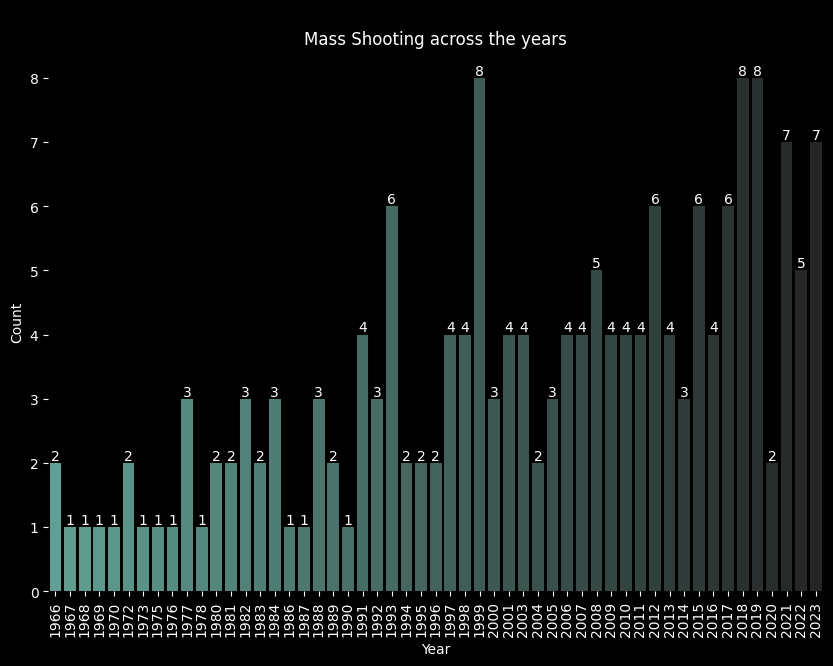

In [11]:
# Distribution of Year
Year_Distribution = df.groupby('Year')['Case_No'].size().reset_index().sort_values(by='Case_No', ascending=False)
Year_Distribution.rename(columns={'Case_No':'Count'}, inplace = True)
plt.figure(figsize = (10,7))
ax = sns.barplot(y = 'Count', x ='Year', data = Year_Distribution, palette='dark:#5A9_r')
ax.set_title('\nMass Shooting across the years')
ax.set(xlabel="Year", ylabel ="Count")
sns.despine(top=True, bottom=True, right = True, left = True)
for bars in ax.containers:
    ax.bar_label(bars)
plt.xticks(rotation = 90)
plt.show()

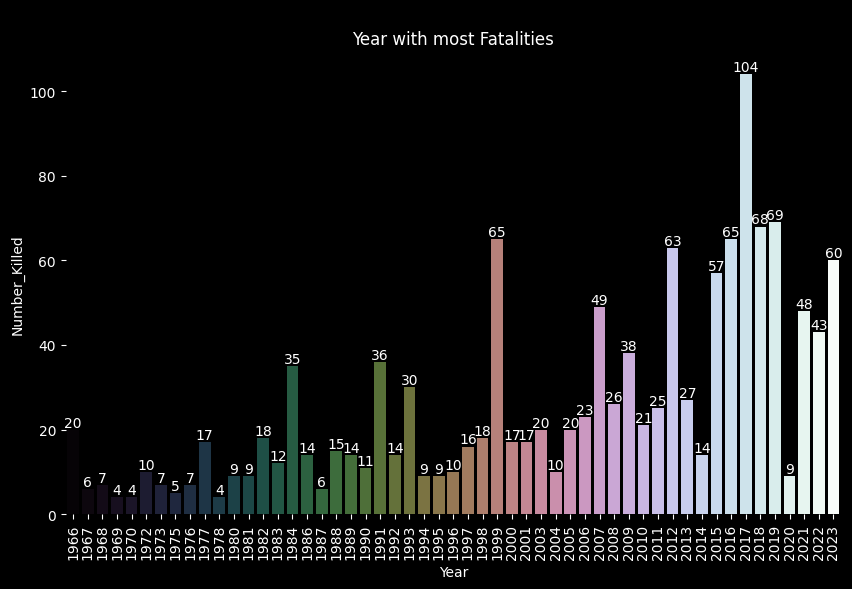

In [12]:
# Year with most fatalities 
Deaths_Year = df.groupby('Year')['Number_Killed'].sum().reset_index().sort_values(by = 'Year', ascending=False)
plt.figure(figsize=(10,6))
ax = sns.barplot(y='Number_Killed', x = 'Year', data=Deaths_Year, palette='cubehelix')
ax.set_title('\nYear with most Fatalities')
ax.set(xlabel="Year", ylabel ="Number_Killed")
sns.despine(top=True, bottom=True, right = True, left = True)
for bars in ax.containers:
    ax.bar_label(bars)
plt.xticks(rotation = 90)
plt.show()

C:\Users\maria\AppData\Local\Temp\ipykernel_19328\3387637009.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  ax = sns.histplot(data = df, x='Age', kde=True, palette='cubehelix')


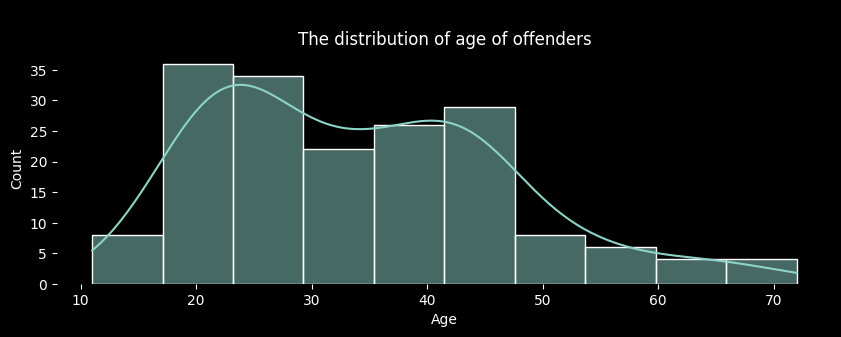

In [13]:
plt.figure(figsize=(10,3))
ax = sns.histplot(data = df, x='Age', kde=True, palette='cubehelix')
ax.set_title('\nThe distribution of age of offenders')
ax.set(xlabel="Age")
sns.despine(top=True, bottom=True, right = True, left = True)
plt.show()

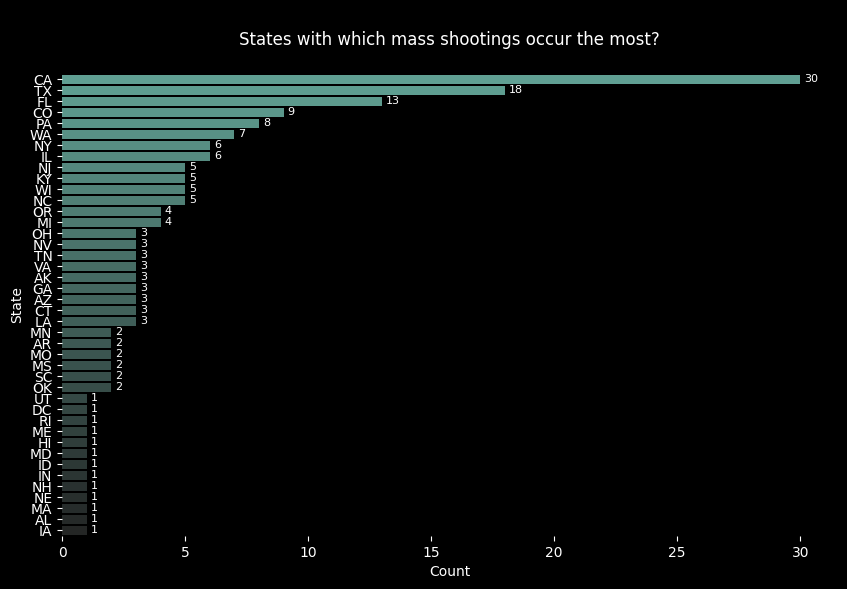

In [14]:
# what state do this shootings occur
State_Dist = df.groupby('State')['Case_No'].size().reset_index().sort_values('Case_No', ascending=False)
State_Dist.rename(columns={'Case_No':'Count'}, inplace=True)
plt.figure(figsize=(10,6))
ax = sns.barplot(x = 'Count', y = 'State', data=State_Dist, palette='dark:#5A9_r')
ax.set_title('\nStates with which mass shootings occur the most?\n')
ax.set(xlabel='Count', ylabel='State')
sns.despine(top=True, bottom=True, right=True, left = True)
for bars in ax.containers:
    ax.bar_label(bars, padding= 3, fontsize = 8)
plt.show()

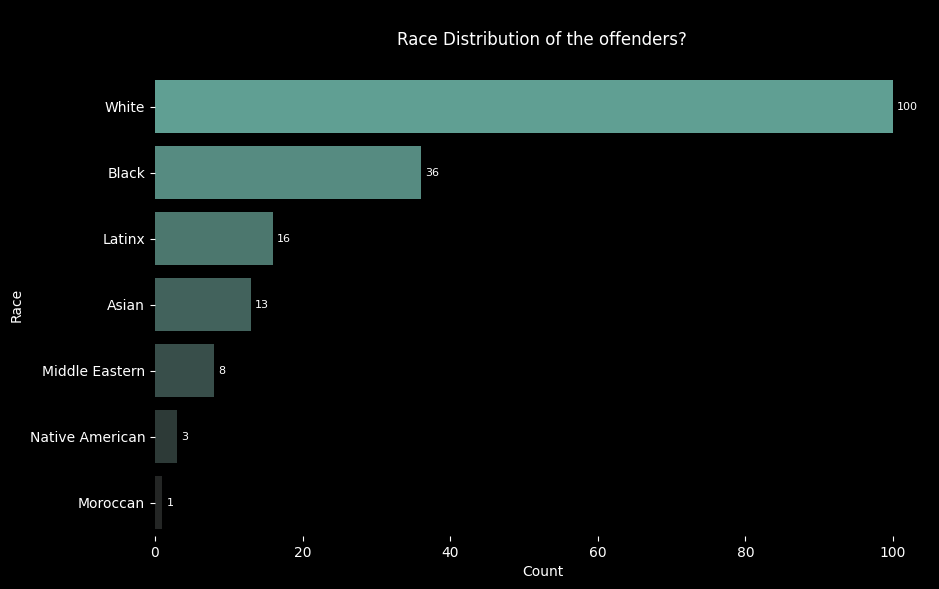

In [15]:
Race_Dist = df.groupby('Race')['Case_No'].count().reset_index(name='Count').sort_values(by='Count', ascending=False)
plt.figure(figsize=(10,6))
ax = sns.barplot(x = 'Count', y = 'Race', data=Race_Dist, palette='dark:#5A9_r')
ax.set_title('\nRace Distribution of the offenders?\n')
ax.set(xlabel='Count', ylabel='Race')
sns.despine(top=True, bottom=True, right=True, left = True)
for bars in ax.containers:
    ax.bar_label(bars, padding= 3, fontsize = 8)
plt.show()

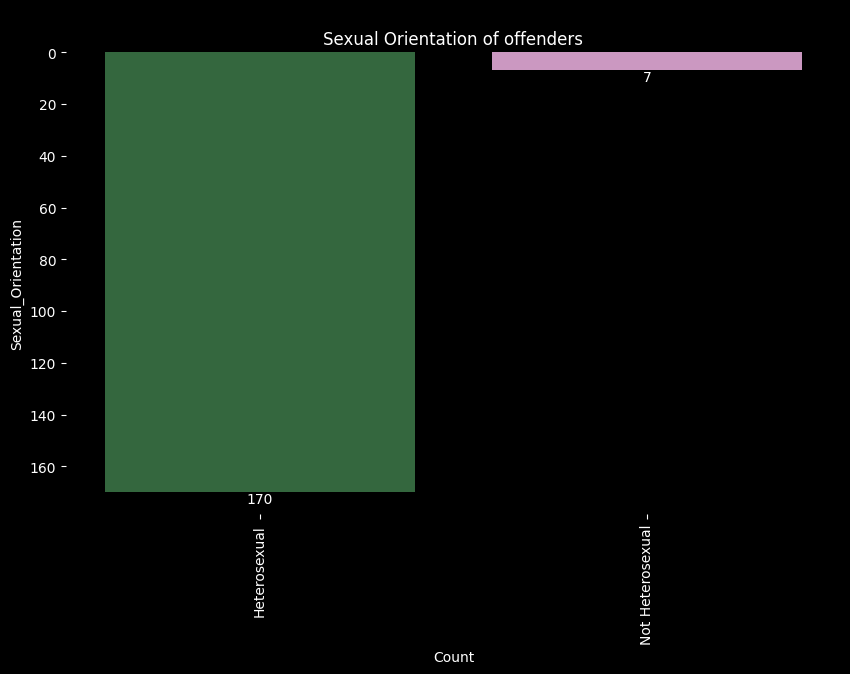

In [16]:
# Sexual Orientation of Offenders
Sexual_Orient = df.groupby('Sexual_Orientation')['Case_No'].size().reset_index().sort_values(by='Case_No', ascending=False)
Sexual_Orient.rename(columns={'Case_No':'Count'}, inplace=True)
plt.figure(figsize=(10,6))
ax = sns.barplot(x='Sexual_Orientation', y = 'Count', data=Sexual_Orient, palette='cubehelix')
ax.set_title('\nSexual Orientation of offenders')
ax.set(ylabel="Sexual_Orientation", xlabel ="Count")
ax.invert_yaxis()
sns.despine(top=True, bottom=True, right = True, left = True)
for bars in ax.containers:
    ax.bar_label(bars)
plt.xticks(rotation = 90)
plt.show()

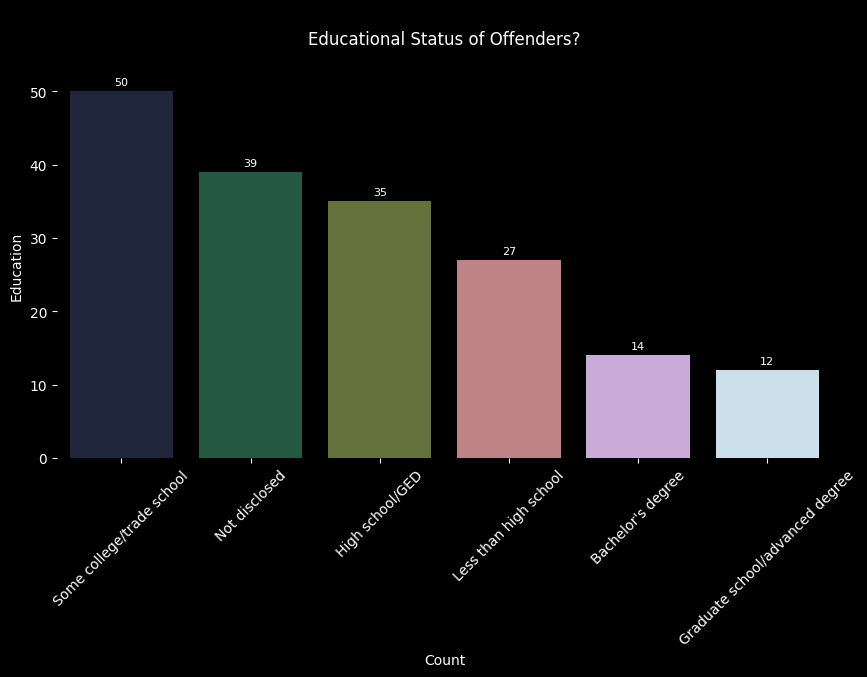

In [17]:
# Educational Status of Offenders
Educational_Status = df.groupby('Education')['Case_No'].size().reset_index(name='Count').sort_values(by='Count', ascending=False)
plt.figure(figsize=(10,5))
ax = sns.barplot(x = 'Education', y = 'Count', data=Educational_Status, palette='cubehelix')
ax.set_title('\nEducational Status of Offenders?\n')
ax.set(xlabel='Count', ylabel='Education')
sns.despine(top=True, bottom=True, right=True, left = True)
for bars in ax.containers:
    ax.bar_label(bars, padding=3, fontsize = 8)
plt.xticks(rotation = 45)
plt.show()

In [18]:
Yes_Military = df[df['Military_Service'] == 'Yes']
Yes_Military

,Case_No,Shooter_Last_Name,Shooter_First_Name,Age,Day_of_Week,Year,Month,Gender,Race,Sexual_Orientation,...,Number_Injured,Victims_Inside___Outside,Workplace_Shooting,Armed_Person_on_Scene,Employment_Status,Military_Service,Employment_Type,Military_Branch,Criminal_Record,Mental_Illness
4,13,Henry,Dewitt,26,Saturday,1977,7,Male,White,Heterosexual,...,2,Outside,0,0.0,0.0,Yes,Blue collar,Navy,0.0,No evidence
9,34,Farley,Richard,39,Tuesday,1988,2,Male,White,Heterosexual,...,4,Inside,1,0.0,1.0,Yes,In between,Navy,0.0,No evidence
10,50,French,Kenneth,22,Friday,1993,8,Male,White,Heterosexual,...,7,Inside,0,0.0,1.0,Yes,Blue collar,Army,0.0,No evidence
11,58,Woods,Willie,42,Wednesday,1995,7,Male,Black,Heterosexual,...,0,Inside,1,0.0,1.0,Yes,Blue collar,Marines,0.0,No evidence
17,91,Vang,Chai,36,Sunday,2004,11,Male,Asian,Heterosexual,...,2,Outside,0,1.0,1.0,Yes,Blue collar,National Guard,1.0,No evidence
29,8,Grace,Edwin,33,Wednesday,1972,6,Male,White,Heterosexual,...,6,Inside,1,0.0,1.0,Yes,Blue collar,Army,1.0,No evidence
30,12,Cowan,Fred,33,Monday,1977,2,Male,White,Heterosexual,...,5,Both inside and outside,1,0.0,1.0,Yes,Blue collar,Army,1.0,No evidence
42,126,Page,Wade,40,Sunday,2012,8,Male,White,Heterosexual,...,3,Both inside and outside,0,0.0,0.0,Yes,Blue collar,Army,1.0,No evidence
48,27,Silka,Michael,25,Thursday,1984,5,Male,White,Heterosexual,...,1,Outside,0,0.0,0.0,Yes,Blue collar,Army,1.0,No evidence
49,65,Torres,Arturo,41,Thursday,1997,12,Male,Latinx,Heterosexual,...,3,Outside,1,0.0,0.0,Yes,Blue collar,Army,0.0,No evidence


C:\Users\maria\AppData\Local\Temp\ipykernel_19328\3906782185.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Criminal_Record'] = df['Criminal_Record'].map(Yes_No_Mapping)
C:\Users\maria\AppData\Local\Temp\ipykernel_19328\3906782185.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Employment_Status'] = df['Employment_Status'].map(Yes_No_Mapping)


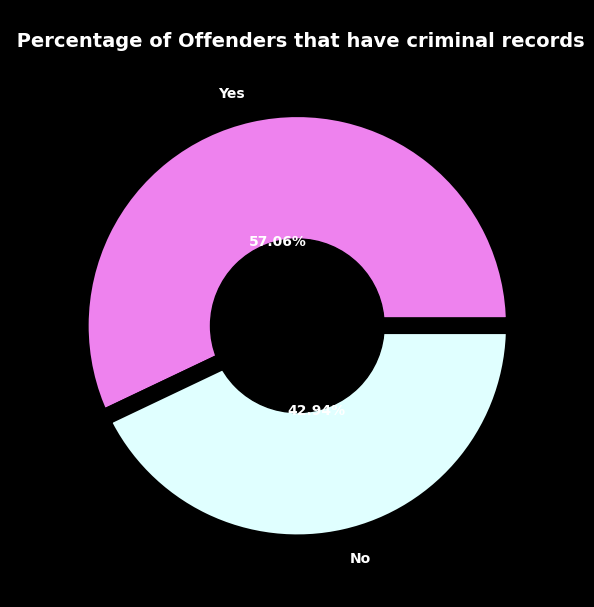

In [19]:
# mapping 0 and 1 answers
Yes_No_Mapping = {1.0:'Yes', 0.0:'No'}
df['Criminal_Record'] = df['Criminal_Record'].map(Yes_No_Mapping)
df['Employment_Status'] = df['Employment_Status'].map(Yes_No_Mapping)
Yes_Criminal = df['Criminal_Record'].value_counts()['Yes']
No_Criminal = df['Criminal_Record'].value_counts()['No']

names = ['Yes', 'No']
size = [Yes_Criminal, No_Criminal]

plt.pie(x=size, labels=names, colors=['violet', 'lightcyan'], 
        autopct='%1.2f%%', pctdistance=0.4, textprops=dict(fontweight='bold'),
        wedgeprops={'linewidth':12, 'edgecolor':'black'})
my_circle = plt.Circle((0,0), 0.4, color='black')

# plot the donut chart
fig = plt.gcf()
fig.set_size_inches(7,10)
fig.gca().add_artist(my_circle)
plt.title('\n Percentage of Offenders that have criminal records', fontsize=14, fontweight='bold')
plt.show()

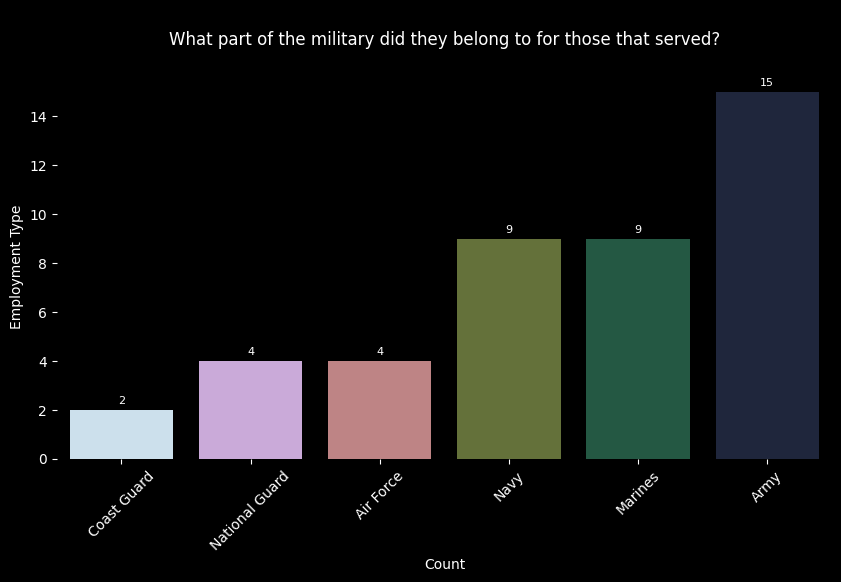

In [20]:
Military_Branch = Yes_Military.groupby('Military_Branch')['Case_No'].count().reset_index(name = 'Count').sort_values(by='Count', ascending=False)
plt.figure(figsize=(10,5))
ax = sns.barplot(x = 'Military_Branch', y = 'Count', data=Military_Branch, palette='cubehelix')
ax.set_title('\nWhat part of the military did they belong to for those that served?\n')
ax.set(xlabel='Count', ylabel='Employment Type')
ax.invert_xaxis()
sns.despine(top=True, bottom=True, right=True, left = True)
for bars in ax.containers:
    ax.bar_label(bars, padding=3, fontsize = 8)
plt.xticks(rotation = 45)
plt.show()

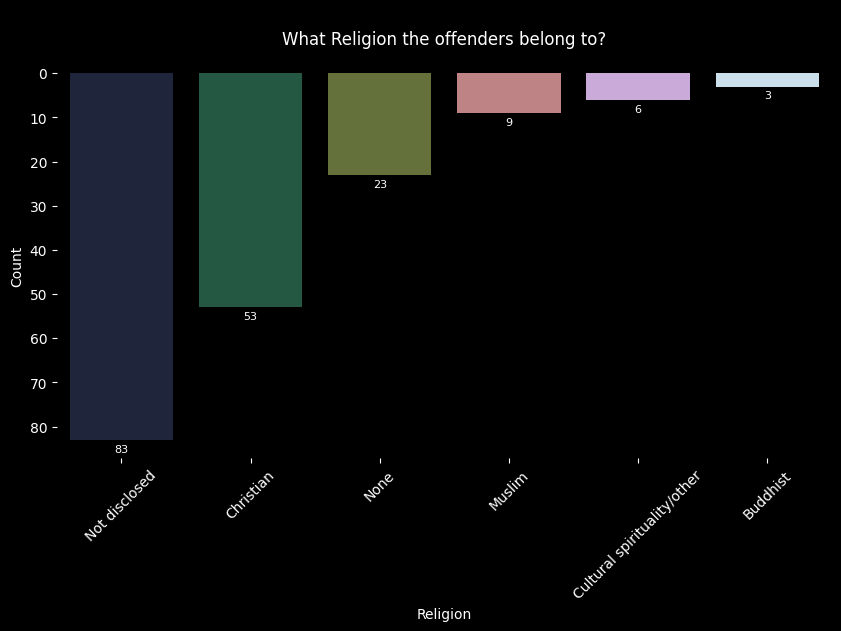

In [21]:
Religion = df.groupby('Religion')['Case_No'].size().reset_index(name='Count').sort_values(by='Count', ascending=False)
plt.figure(figsize=(10,5))
ax = sns.barplot(x = 'Religion', y = 'Count', data=Religion, palette='cubehelix')
ax.set_title('\nWhat Religion the offenders belong to?\n')
ax.set(xlabel='Religion', ylabel='Count')
ax.invert_yaxis()
sns.despine(top=True, bottom=True, right=True, left = True)
for bars in ax.containers:
    ax.bar_label(bars, padding=3, fontsize = 8)
plt.xticks(rotation = 45)
plt.show()

In [22]:
Yes_No_Mapping = {1.0:'Yes', 0.0:'No'}
Yes_No = {1:'Yes', 0:'No'}
df['Armed_Person_on_Scene'] = df['Armed_Person_on_Scene'].map(Yes_No_Mapping)
df['Workplace_Shooting'] = df['Workplace_Shooting'].map(Yes_No)


C:\Users\maria\AppData\Local\Temp\ipykernel_19328\2510655949.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Armed_Person_on_Scene'] = df['Armed_Person_on_Scene'].map(Yes_No_Mapping)
C:\Users\maria\AppData\Local\Temp\ipykernel_19328\2510655949.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Workplace_Shooting'] = df['Workplace_Shooting'].map(Yes_No)


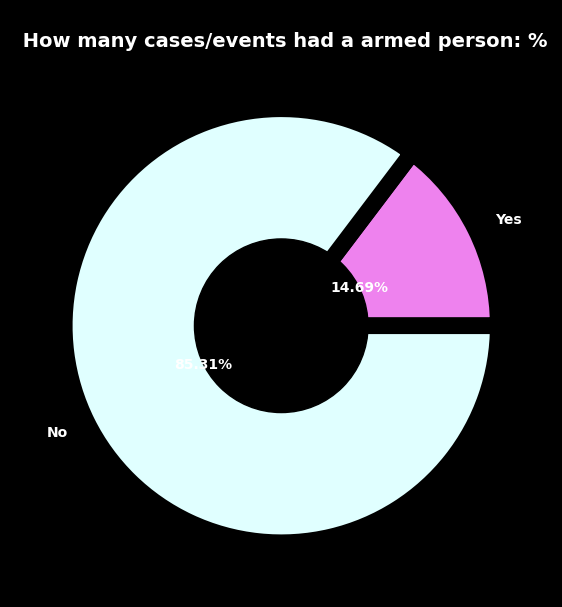

In [23]:
Yes_Armed = df['Armed_Person_on_Scene'].value_counts()['Yes']
No_Armed = df['Armed_Person_on_Scene'].value_counts()['No']

names = ['Yes', 'No']
size = [Yes_Armed, No_Armed]

plt.pie(x=size, labels=names, colors=['violet', 'lightcyan'], 
        autopct='%1.2f%%', pctdistance=0.4, textprops=dict(fontweight='bold'),
        wedgeprops={'linewidth':12, 'edgecolor':'black'})
my_circle = plt.Circle((0,0), 0.4, color='black')

# plot the donut chart
fig = plt.gcf()
fig.set_size_inches(7,10)
fig.gca().add_artist(my_circle)
plt.title('\n How many cases/events had a armed person: %', fontsize=14, fontweight='bold')
plt.show()

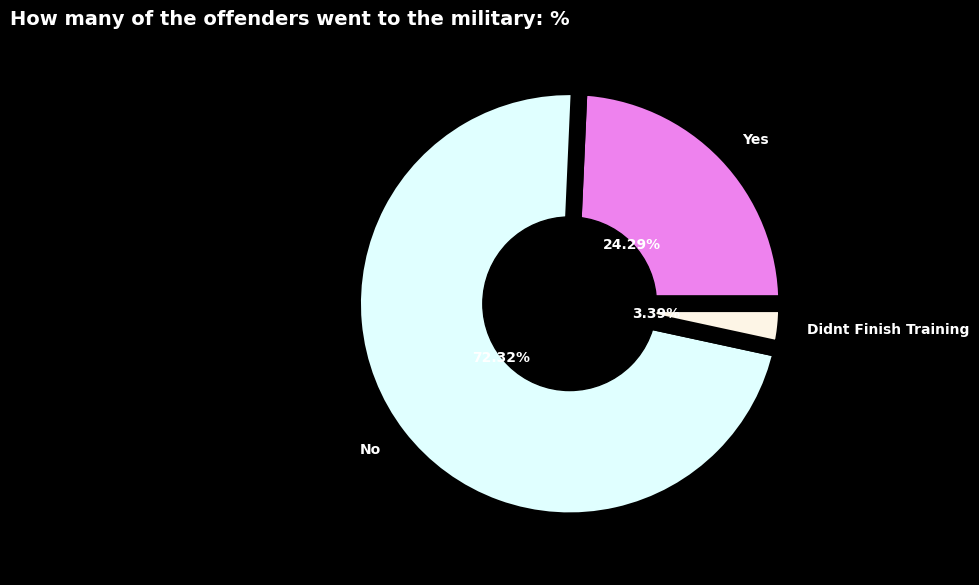

In [24]:
Yes_Military  = df['Military_Service'].value_counts()['Yes']
No_Military = df['Military_Service'].value_counts()['No']
Untrained_Military = df['Military_Service'].value_counts()['Joined but did not make it through training']
names = ['Yes', 'No', 'Didnt Finish Training']
size = [Yes_Military, No_Military, Untrained_Military]

plt.pie(x=size, labels=names, colors=['violet', 'lightcyan', 'oldlace'], 
        autopct='%1.2f%%', pctdistance=0.4, textprops=dict(fontweight='bold'),
        wedgeprops={'linewidth':12, 'edgecolor':'black'})
my_circle = plt.Circle((0,0), 0.4, color='black')

# plot the donut chart
fig = plt.gcf()
fig.set_size_inches(7,10)
fig.gca().add_artist(my_circle)
plt.title('How many of the offenders went to the military: %', fontsize=14, fontweight='bold', ha = 'right')
plt.show()


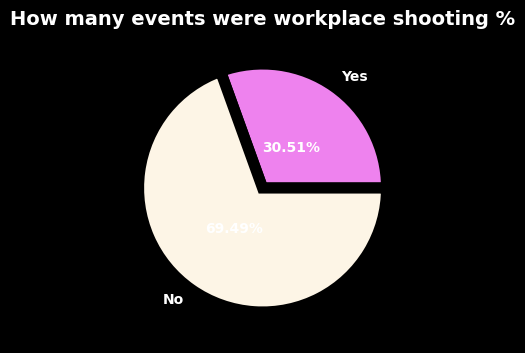

In [25]:
Yes_Workplace = df['Workplace_Shooting'].value_counts()['Yes']
No_Workplace = df['Workplace_Shooting'].value_counts()['No']

names = ['Yes', 'No']
size = [Yes_Workplace, No_Workplace]

plt.pie(x=size, labels=names, colors=['violet', 'oldlace'], 
        autopct='%1.2f%%', pctdistance=0.4, textprops=dict(fontweight='bold'),
        wedgeprops={'linewidth':8, 'edgecolor':'black'})
# plot the donut chart
fig = plt.gcf()
fig.set_size_inches(4,6)
plt.title('How many events were workplace shooting %', fontsize=14, fontweight='bold', ha = 'center')
plt.show()


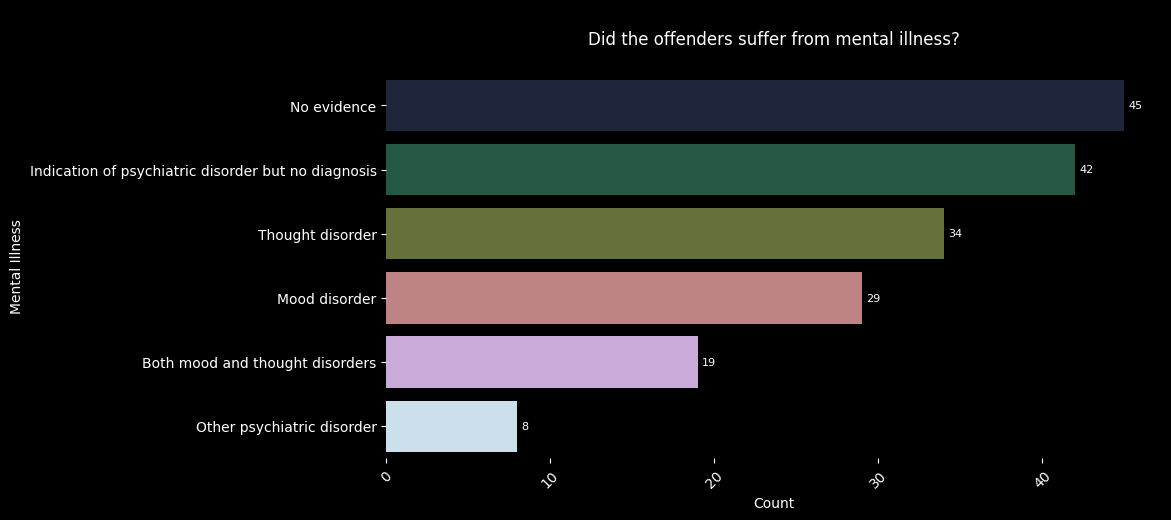

In [26]:
Mental_Illness_Dist = df.groupby('Mental_Illness')['Case_No'].count().reset_index(name = 'Count').sort_values(by='Count', ascending = False)
plt.figure(figsize=(10,5))
ax = sns.barplot(x = 'Count', y = 'Mental_Illness', data=Mental_Illness_Dist, palette='cubehelix')
ax.set_title('\nDid the offenders suffer from mental illness?\n')
ax.set(xlabel='Count', ylabel='Mental Illness')
sns.despine(top=True, bottom=True, right=True, left = True)
for bars in ax.containers:
    ax.bar_label(bars, padding=3, fontsize = 8)
plt.xticks(rotation = 45)
plt.show()

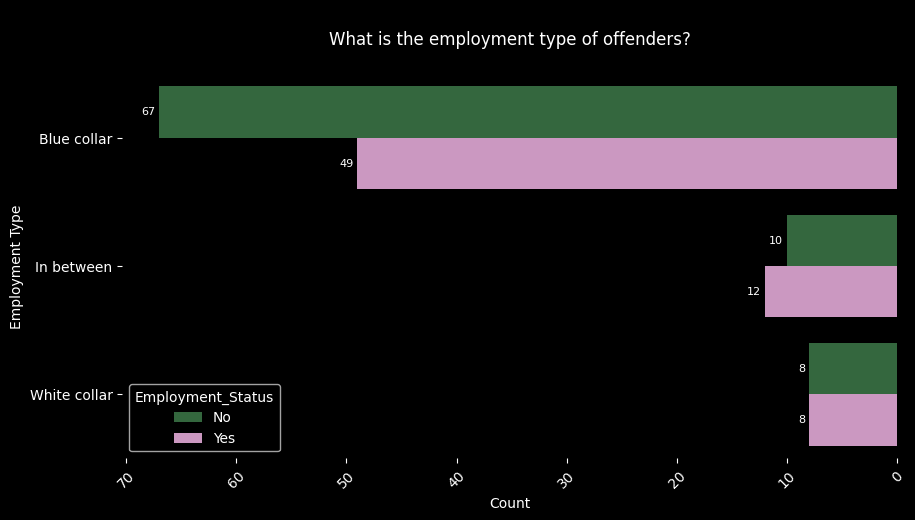

In [27]:
Employment_status_type = df.groupby(['Employment_Type', 'Employment_Status'])['Case_No'].count().reset_index(name = 'Count').sort_values(by='Count', ascending=False)
plt.figure(figsize=(10,5))
ax = sns.barplot(x = 'Count', y = 'Employment_Type',hue ='Employment_Status', data=Employment_status_type, palette='cubehelix')
ax.set_title('\nWhat is the employment type of offenders?\n')
ax.set(xlabel='Count', ylabel='Employment Type')
ax.invert_xaxis()
sns.despine(top=True, bottom=True, right=True, left = True)
for bars in ax.containers:
    ax.bar_label(bars, padding=3, fontsize = 8)
plt.xticks(rotation = 45)
plt.show()

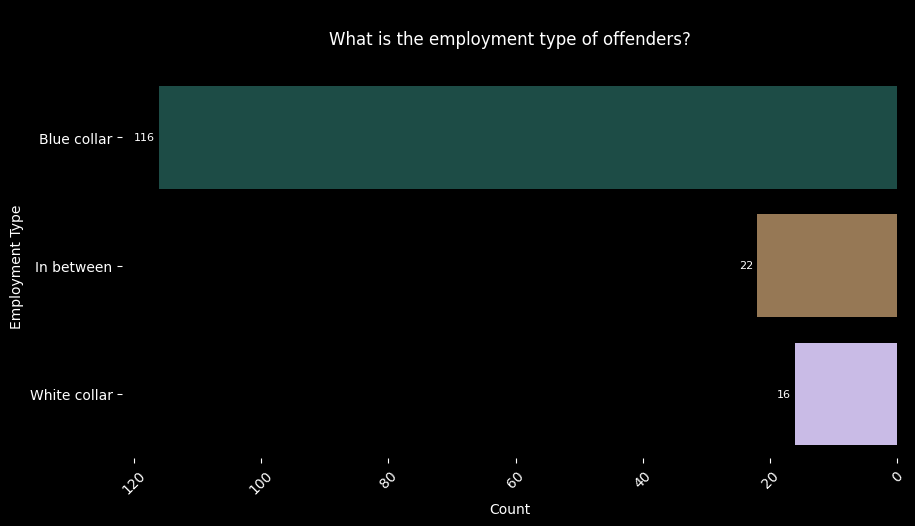

In [28]:
Employment_status = df.groupby('Employment_Type')['Case_No'].count().reset_index(name = 'Count').sort_values(by='Count', ascending=False)
plt.figure(figsize=(10,5))
ax = sns.barplot(x = 'Count', y = 'Employment_Type', data=Employment_status, palette='cubehelix')
ax.set_title('\nWhat is the employment type of offenders?\n')
ax.set(xlabel='Count', ylabel='Employment Type')
ax.invert_xaxis()
sns.despine(top=True, bottom=True, right=True, left = True)
for bars in ax.containers:
    ax.bar_label(bars, padding=3, fontsize = 8)
plt.xticks(rotation = 45)
plt.show()

In [29]:
df.shape

(177, 26)